# Final Project Into to Machine Learning
This python notebook is divided in 4 sections:
1. Data preprocessing
2. Neural Network Model
3. SVM Model
4. Logistic Regression Model

# Data Preprocessing

All necessary imports

In [9]:
import pandas as pd
import numpy as np
import numpy.random as r
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, confusion_matrix
)

np.random.seed(42)

Load the dataset

In [10]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Check missing values

In [11]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

Check target distribution

In [12]:
df["track_genre"].value_counts().head(20)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
Name: count, dtype: int64

Find the 10 most common genres, then make a new dataset that only includes songs from those genres.

In [13]:
top_10 = df["track_genre"].value_counts().head(10).index.tolist()

df_filtered = df[df["track_genre"].isin(top_10)].copy()

df_small = (
    df_filtered.groupby("track_genre", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

print(df_small.shape)
print(df_small["track_genre"].value_counts())

(2000, 21)
track_genre
acoustic             200
opera                200
pagode               200
party                200
piano                200
pop                  200
pop-film             200
power-pop            200
progressive-house    200
punk-rock            200
Name: count, dtype: int64


Select numeric audio features

In [14]:
features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

target = "track_genre"

X = df_small[features].copy()
y = df_small[target].copy()

print(X.shape)
print(y.shape)

(2000, 14)
(2000,)


Encode genre labels

In [15]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Genres:", list(label_encoder.classes_))

Genres: ['acoustic', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'punk-rock']


Train/validation/test split. 700 training songs, 150 validation songs, 150 test songs.

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1400, 14)
Validation shape: (300, 14)
Test shape: (300, 14)


Scale the features using StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Neural Network
In this section we train 5 Neural Network Architectures (each with 6 different regularization values):
1. T0_Linear: [14, 10]
2. T1_Shallow: [14, 30, 10]
3. T2_DeeperNarrow: [14,20,20,10]
4. T3_Wider: [14,64,10]
5. T4_DeepWide: [14,64,32,10]

One hot encode targets

In [34]:
def to_onehot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

y_v_train = to_onehot(y_train)
y_v_val = to_onehot(y_val)
y_v_test = to_onehot(y_test)

#Print statements to verify
print("y_v_train shape:", y_v_train.shape)
print("Example one-hot:", y_v_train[0])

y_v_train shape: (1400, 10)
Example one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


Activation Functions:
- Relu for hidden layer
- Softmax for output layer


In [35]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

Xavier weight initialization to maximize model performance

In [36]:
def init_weights(nn_structure, seed=42):
    np.random.seed(seed)
    W, b = {}, {}
    for l in range(1, len(nn_structure)):
        fan_in = nn_structure[l - 1]
        W[l] = np.random.randn(nn_structure[l], fan_in) * np.sqrt(1.0/fan_in)
        b[l] = np.zeros(nn_structure[l])
    return W, b

def init_grads(nn_structure):
    tri_W, tri_b = {}, {}
    for l in range(1, len(nn_structure)):
        tri_W[l] = np.zeros((nn_structure[l], nn_structure[l-1]))
        tri_b[l] = np.zeros(nn_structure[l])
    return tri_W, tri_b

Feed forward function: Relu for hidden layer and Softmax for output

In [37]:
def feed_forward(x, W, b):
    n_layers = len(W)
    a = {1: x}
    z = {}
    for l in range(1, n_layers + 1):
        z[l+1] = W[l].dot(a[l]) + b[l]
        if l < n_layers:         
            a[l+1] = relu(z[l+1])
        else:                     
            a[l+1] = softmax(z[l+1])
    return a, z

Compute the cross-entropy between the 10 probabilites at output. Cross-entropy using -log gives a greater cost for probabilities which forces faster correction during training.

In [38]:
def cross_entropy(y_true, y_pred):
    eps = 1e-12
    return -np.sum(y_true * np.log(y_pred + eps))

def compute_cost_batch(Y_true, X, W, b, lambda_reg):
    N = X.shape[0]
    total = 0.0
    for i in range(N):
        a, _ = feed_forward(X[i], W, b)
        total += cross_entropy(Y_true[i], a[len(W)+1])
    total /= N
    #L2 penalty
    l2 = (lambda_reg / 2) * sum(np.sum(W[l]**2) for l in W)
    return total + l2

Backpropagation & Training

In [39]:
def train_nn(nn_structure, X_train, y_v_train, X_val, y_v_val, n_iter=2000, alpha=0.05, lambda_reg=0.01, seed=42, verbose=True):

    W, b = init_weights(nn_structure, seed=seed)
    n_layers = len(W)
    N = X_train.shape[0]
    train_costs, val_costs = [], []

    if verbose:
        print(f' Training {nn_structure}, λ={lambda_reg}, α={alpha}')

    for cnt in range(n_iter):
        tri_W, tri_b = init_grads(nn_structure)

        for i in range(N):
            a, z = feed_forward(X_train[i], W, b)
            delta = {}

            #Output layer
            delta[n_layers + 1] = a[n_layers + 1] - y_v_train[i]

            #Hidden layer
            for l in range(n_layers, 1, -1):
                delta[l] = W[l].T.dot(delta[l+1]) * relu_deriv(z[l])

            #Accumulate gradients
            for l in range(1, n_layers + 1):
                tri_W[l] += np.outer(delta[l+1], a[l])
                tri_b[l] += delta[l+1]

        #Gradient descent
        for l in range(1, n_layers + 1):
            W[l] -= alpha * (tri_W[l] / N + lambda_reg * W[l])
            b[l] -= alpha * (tri_b[l] / N)

        #Record costs every 100 iterations to save time
        if cnt % 100 == 0:
            tc = compute_cost_batch(y_v_train, X_train, W, b, lambda_reg)
            vc = compute_cost_batch(y_v_val,   X_val,   W, b, lambda_reg)
            train_costs.append(tc)
            val_costs.append(vc)

    return W, b, train_costs, val_costs


def predict(W, b, X):
    n_layers = len(W) + 1
    preds = []
    for i in range(X.shape[0]):
        a, _ = feed_forward(X[i], W, b)
        preds.append(np.argmax(a[n_layers]))
    return np.array(preds)

Architectures and regularization values

In [40]:
ARCHITECTURES = {
    "T0_Linear": [14, 10],
    "T1_Shallow": [14, 30, 10],
    "T2_DeeperNarrow":[14, 20, 20, 10],
    "T3_Wider": [14, 64, 10],
    "T4_DeepWide": [14, 64, 32, 10],
}

LAMBDA_VALUES = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]

#Hyperparameters
N_ITER = 2000
ALPHA = 0.05

This is where the experiments take place

In [41]:
results = [] #list of result dicts whic will become the results table
curves = {} #{(arch_name, lambda): (train_costs, val_costs)}
models = {} #{(arch_name, lambda): (W, b)}, and keep best for final eval

for arch_name, nn_structure in ARCHITECTURES.items():
    print(f"Architecture: {arch_name} {nn_structure}")

    for lam in LAMBDA_VALUES:
        W, b, train_costs, val_costs = train_nn(nn_structure, X_train_scaled, y_v_train,X_val_scaled, y_v_val,n_iter=N_ITER, alpha=ALPHA, lambda_reg=lam,verbose=True)

        #Evaluate on train and validation
        y_pred_train = predict(W, b, X_train_scaled)
        y_pred_val = predict(W, b, X_val_scaled)

        train_acc = accuracy_score(y_train, y_pred_train)
        val_acc = accuracy_score(y_val, y_pred_val)
        val_prec = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_rec = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_f1 = f1_score(y_val, y_pred_val, average='macro', zero_division=0)

        results.append({
            'Architecture': arch_name,
            'Structure': str(nn_structure),
            'Lambda': lam,
            'Train Acc':round(train_acc, 4),
            'Val Acc':round(val_acc, 4),
            'Val Precision': round(val_prec, 4),
            'Val Recall': round(val_rec, 4),
            'Val F1': round(val_f1, 4),
            'Final Train Loss': round(train_costs[-1], 4),
            'Final Val Loss': round(val_costs[-1], 4),
        })

        curves[(arch_name, lam)] = (train_costs, val_costs)
        models[(arch_name, lam)] = (W, b)


print("\nAll experiments complete.")

Architecture: T0_Linear [14, 10]
 Training [14, 10], λ=0, α=0.05
 Training [14, 10], λ=0.0001, α=0.05
 Training [14, 10], λ=0.001, α=0.05
 Training [14, 10], λ=0.01, α=0.05
 Training [14, 10], λ=0.1, α=0.05
 Training [14, 10], λ=1.0, α=0.05
Architecture: T1_Shallow [14, 30, 10]
 Training [14, 30, 10], λ=0, α=0.05
 Training [14, 30, 10], λ=0.0001, α=0.05
 Training [14, 30, 10], λ=0.001, α=0.05
 Training [14, 30, 10], λ=0.01, α=0.05
 Training [14, 30, 10], λ=0.1, α=0.05
 Training [14, 30, 10], λ=1.0, α=0.05
Architecture: T2_DeeperNarrow [14, 20, 20, 10]
 Training [14, 20, 20, 10], λ=0, α=0.05
 Training [14, 20, 20, 10], λ=0.0001, α=0.05
 Training [14, 20, 20, 10], λ=0.001, α=0.05
 Training [14, 20, 20, 10], λ=0.01, α=0.05
 Training [14, 20, 20, 10], λ=0.1, α=0.05
 Training [14, 20, 20, 10], λ=1.0, α=0.05
Architecture: T3_Wider [14, 64, 10]
 Training [14, 64, 10], λ=0, α=0.05
 Training [14, 64, 10], λ=0.0001, α=0.05
 Training [14, 64, 10], λ=0.001, α=0.05
 Training [14, 64, 10], λ=0.01, α

### Results of NN


In [ ]:
results_df = pd.DataFrame(results)

print(results_df[['Architecture','Lambda','Train Acc','Val Acc', Val,'Val F1']].to_string(index=False))
#export to xlsx
results_df.to_excel("nn_results.xlsx", index=False)

#Best row
best_per_arch = results_df.loc[results_df.groupby('Architecture')['Val Acc'].idxmax()]

print("Best model per architecture")
best_per_arch[['Architecture','Lambda','Train Acc','Val Acc','Val F1']]

   Architecture  Lambda  Train Acc  Val Acc  Val F1
      T0_Linear  0.0000     0.5836   0.6367  0.6250
      T0_Linear  0.0001     0.5836   0.6367  0.6250
      T0_Linear  0.0010     0.5836   0.6333  0.6203
      T0_Linear  0.0100     0.5821   0.6233  0.6089
      T0_Linear  0.1000     0.5571   0.6000  0.5810
      T0_Linear  1.0000     0.5079   0.5433  0.4918
     T1_Shallow  0.0000     0.6900   0.6733  0.6741
     T1_Shallow  0.0001     0.6893   0.6733  0.6741
     T1_Shallow  0.0010     0.6879   0.6767  0.6775
     T1_Shallow  0.0100     0.6571   0.6600  0.6592
     T1_Shallow  0.1000     0.5143   0.5167  0.4618
     T1_Shallow  1.0000     0.1000   0.1000  0.0182
T2_DeeperNarrow  0.0000     0.7029   0.6500  0.6524
T2_DeeperNarrow  0.0001     0.7014   0.6500  0.6524
T2_DeeperNarrow  0.0010     0.6957   0.6467  0.6487
T2_DeeperNarrow  0.0100     0.6714   0.6733  0.6736
T2_DeeperNarrow  0.1000     0.3114   0.2967  0.2457
T2_DeeperNarrow  1.0000     0.1000   0.1000  0.0182
       T3_Wi

,Architecture,Lambda,Train Acc,Val Acc,Val F1
0,T0_Linear,0.000,0.5836,0.6367,0.6250
8,T1_Shallow,0.001,0.6879,0.6767,0.6775
15,T2_DeeperNarrow,0.010,0.6714,0.6733,0.6736
18,T3_Wider,0.000,0.7164,0.6867,0.6863
26,T4_DeepWide,0.001,0.7843,0.6833,0.6847


In [48]:
#Overall best
best_row = results_df.loc[results_df['Val Acc'].idxmax()]
print(f"Overall best: {best_row['Architecture']}, λ={best_row['Lambda']}, Val Acc={best_row['Val Acc']}")

Overall best: T3_Wider, λ=0.0, Val Acc=0.6867


### Plots

Plot 1: Validation Accuracy vs Lambda, per architecture

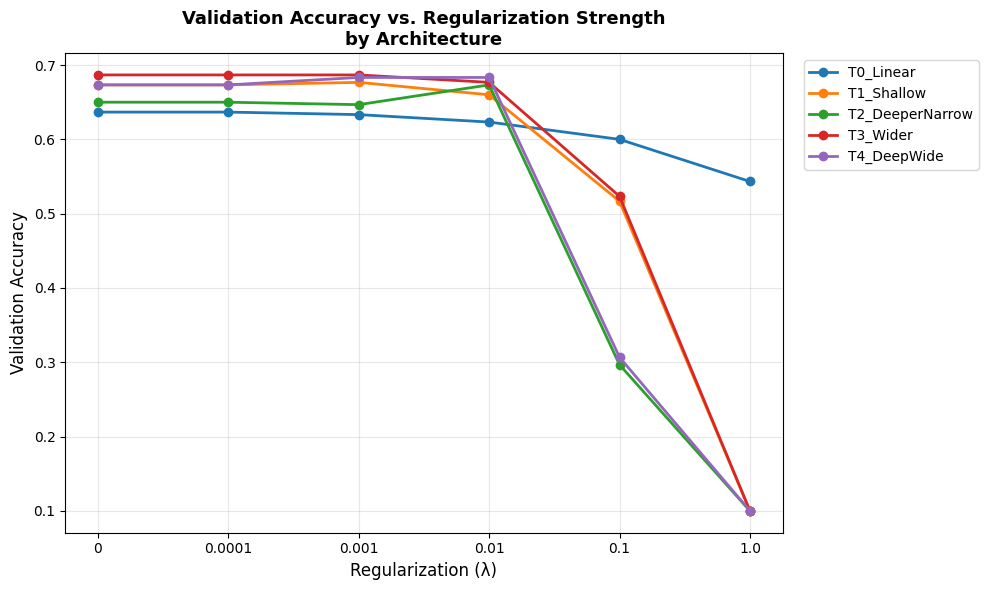

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
lambda_labels = [str(l) for l in LAMBDA_VALUES]
x = np.arange(len(LAMBDA_VALUES))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    ax.plot(x, arch_results['Val Acc'].values, marker='o', linewidth=2,color=colors[i], label=arch_name)

ax.set_xticks(x)
ax.set_xticklabels(lambda_labels)
ax.set_xlabel('Regularization (λ)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs. Regularization Strength\nby Architecture', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot 2: Learning curves for each architecture at lambda = 0.001

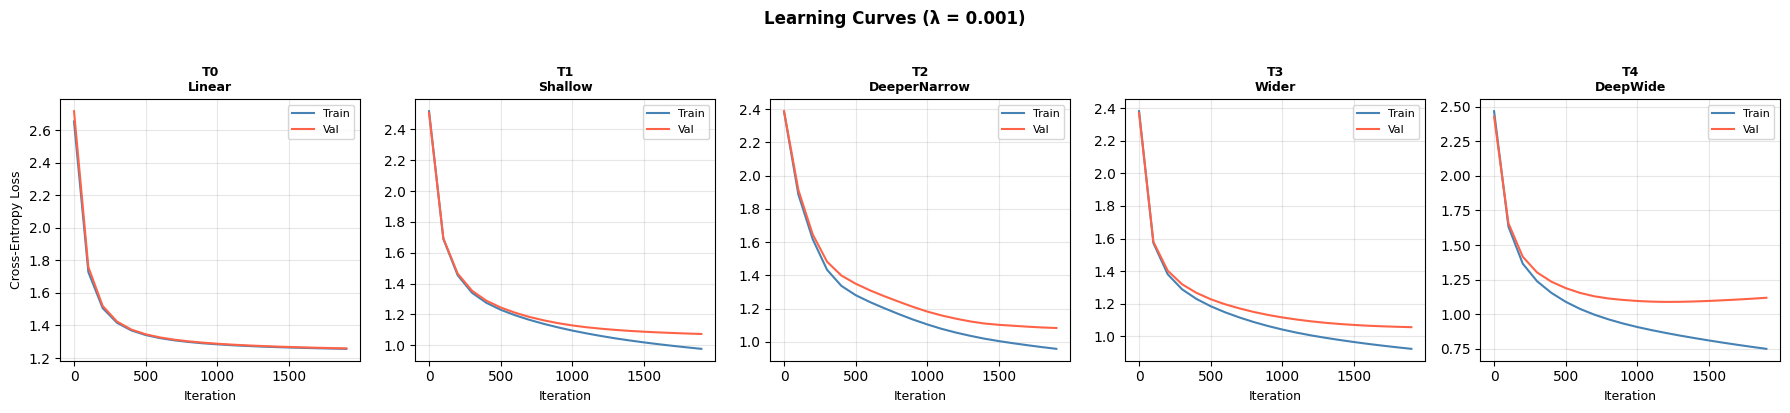

In [98]:
PLOT_LAMBDA = 0.001
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 4), sharey=False)

for i, arch_name in enumerate(ARCHITECTURES):
    tc, vc = curves[(arch_name, PLOT_LAMBDA)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Iteration', fontsize=9)
    if i == 0:
        axes[i].set_ylabel('Cross-Entropy Loss', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves (λ = {PLOT_LAMBDA})', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Plot 3: Train vs Val accuracy (bias-variance view)


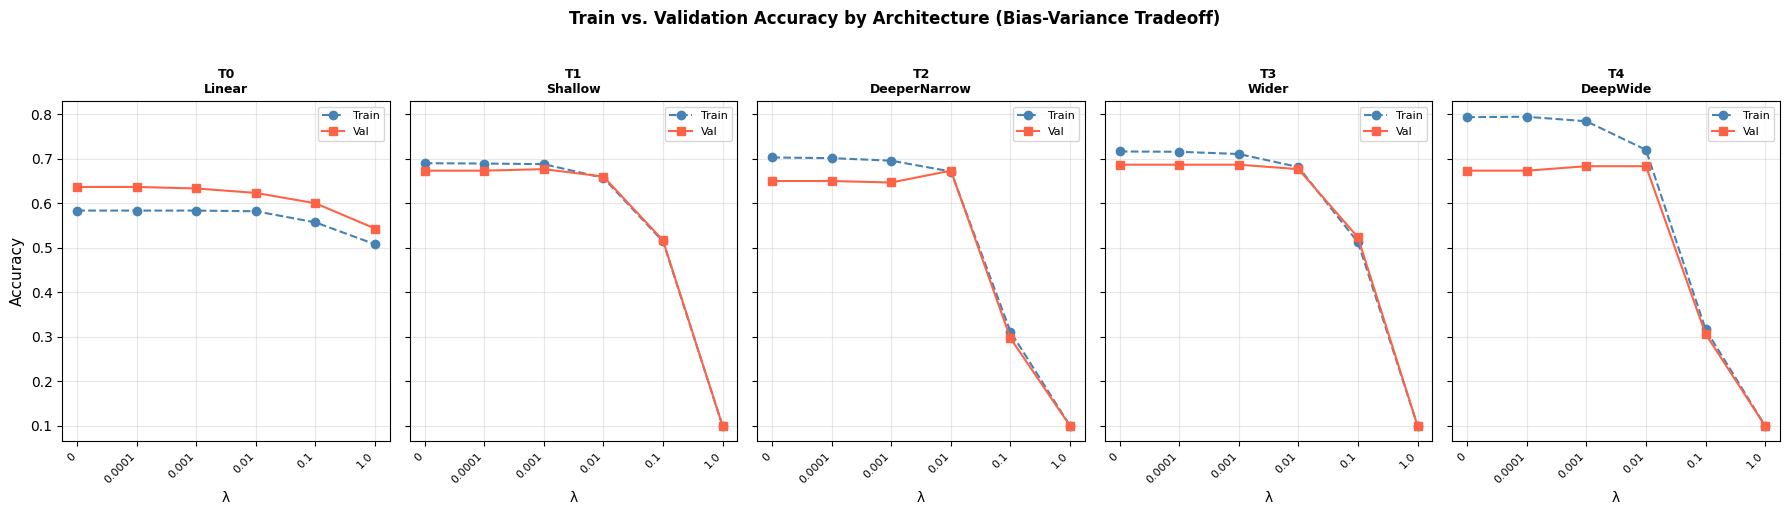

In [99]:
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 5), sharey=True)

for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    x = np.arange(len(LAMBDA_VALUES))
    axes[i].plot(x, arch_results['Train Acc'].values, 'o--', color='steelblue', label='Train')
    axes[i].plot(x, arch_results['Val Acc'].values,   's-',  color='tomato',    label='Val')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(l) for l in LAMBDA_VALUES], rotation=45, ha='right', fontsize=8)
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('λ', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=11)
    axes[i].legend(fontsize=8)

fig.suptitle('Train vs. Validation Accuracy by Architecture (Bias-Variance Tradeoff)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Plot 4: Precision, Recall, F1 for best model per architecture


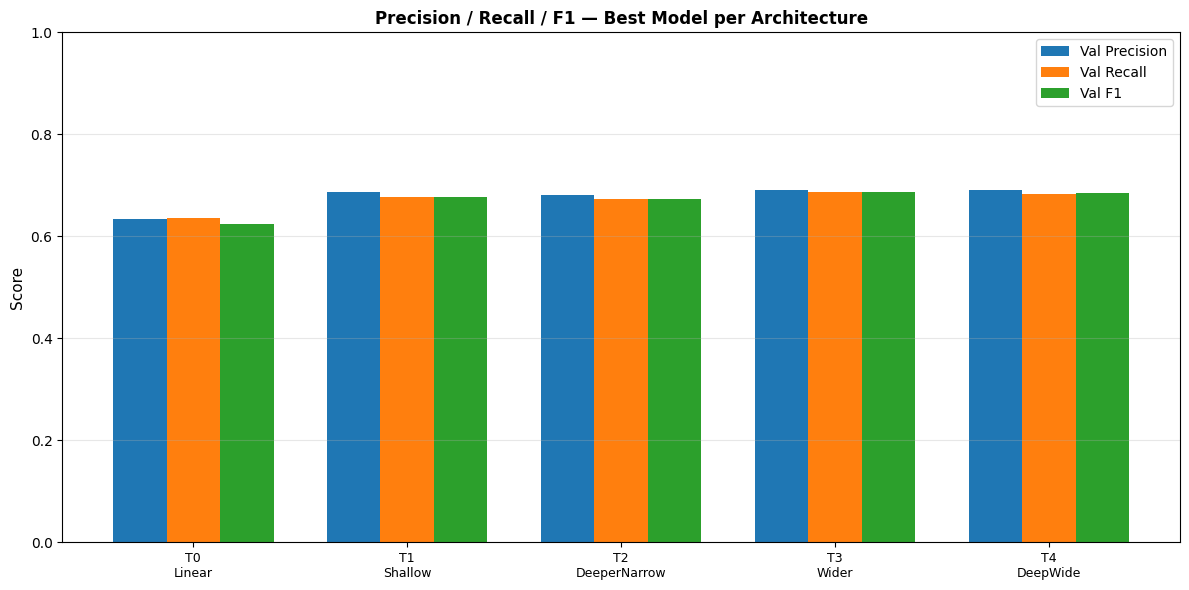

In [100]:
metrics = ['Val Precision', 'Val Recall', 'Val F1']
x = np.arange(len(ARCHITECTURES))
width = 0.25
arch_names = list(ARCHITECTURES.keys())

fig, ax = plt.subplots(figsize=(12, 6))
for j, metric in enumerate(metrics):
    vals = [best_per_arch[best_per_arch['Architecture'] == a][metric].values[0]
            for a in arch_names]
    ax.bar(x + j*width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels([a.replace('_', '\n') for a in arch_names], fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1 — Best Model per Architecture', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Plot 5: Learning curves for best architecture across all lambda values


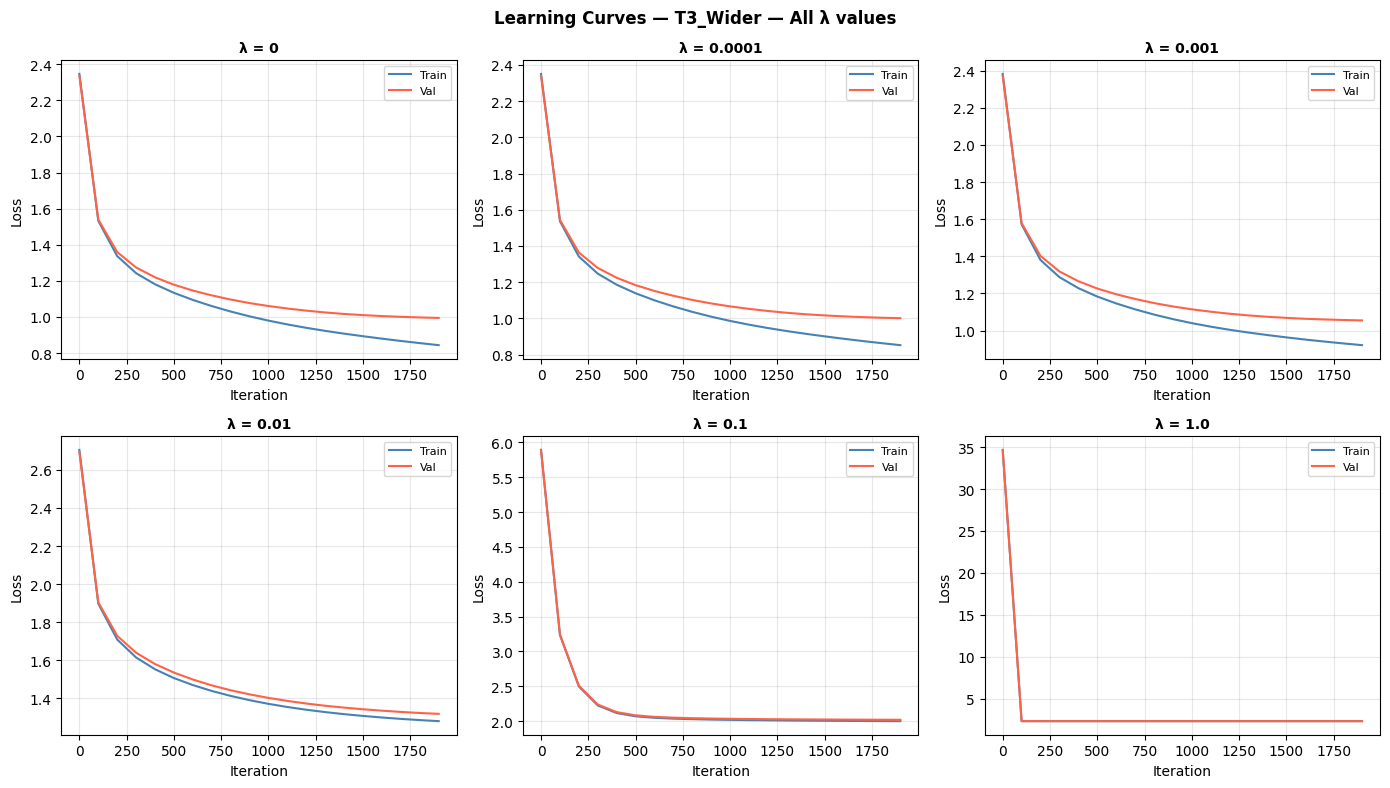

In [101]:
BEST_ARCH = best_row['Architecture']
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, lam in enumerate(LAMBDA_VALUES):
    tc, vc = curves[(BEST_ARCH, lam)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(f'λ = {lam}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves — {BEST_ARCH} — All λ values',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Final eval on test set

In [102]:
for i in range(len(best_per_arch)):
    best_arch = best_per_arch.iloc[i]['Architecture']
    best_lam  = best_per_arch.iloc[i]['Lambda']
    val_acc   = best_per_arch.iloc[i]['Val Acc']
    val_f1    = best_per_arch.iloc[i]['Val F1']

    print(f"Best model for {best_arch}: λ={best_lam}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")
    print("-" * 50)

    W_best, b_best = models[(best_arch, best_lam)]

    # Evaluate on test set
    y_pred_test = predict(W_best, b_best, X_test_scaled)

    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    print(f"TEST Accuracy: {test_acc:.4f}")
    print(f"TEST Precision: {test_prec:.4f}")
    print(f"TEST Recall: {test_rec:.4f}")
    print(f"TEST F1: {test_f1:.4f}")
    print("\nClassification Report:")
    # print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


# print("Full Classification Report:")
# print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

Best model for T0_Linear: λ=0.0, Val Acc=0.6367, Val F1=0.6250
--------------------------------------------------
TEST Accuracy: 0.6033
TEST Precision: 0.6007
TEST Recall: 0.6033
TEST F1: 0.5967

Classification Report:
Best model for T1_Shallow: λ=0.001, Val Acc=0.6767, Val F1=0.6775
--------------------------------------------------
TEST Accuracy: 0.6533
TEST Precision: 0.6585
TEST Recall: 0.6533
TEST F1: 0.6525

Classification Report:
Best model for T2_DeeperNarrow: λ=0.01, Val Acc=0.6733, Val F1=0.6736
--------------------------------------------------
TEST Accuracy: 0.6367
TEST Precision: 0.6443
TEST Recall: 0.6367
TEST F1: 0.6342

Classification Report:
Best model for T3_Wider: λ=0.0, Val Acc=0.6867, Val F1=0.6863
--------------------------------------------------
TEST Accuracy: 0.6767
TEST Precision: 0.6816
TEST Recall: 0.6767
TEST F1: 0.6740

Classification Report:
Best model for T4_DeepWide: λ=0.001, Val Acc=0.6833, Val F1=0.6847
------------------------------------------------

# SVM

In [103]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC

### Feature Tansformations (to be used later in logistic regression as well)

Log-tranformed features

In [104]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

for col in ["duration_ms", "tempo", "popularity"]:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

PCA features

In [105]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (1400, 14)
PCA shape: (1400, 12)


/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_

Polynomial features

In [106]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Polynomial shape:", X_train_poly.shape)

Polynomial shape: (1400, 119)


Store the 4 feature sets

In [107]:
svm_feature_sets = {
    "original": (X_train_scaled, X_val_scaled, X_test_scaled),
    "pca": (X_train_pca, X_val_pca, X_test_pca),
    "polynomial": (X_train_poly, X_val_poly, X_test_poly),
    "log": (X_train_log_scaled, X_val_log_scaled, X_test_log_scaled)
}

Training the models with 6 different regularization values

In [108]:
svm_results = []
C_values = [0.01, 0.1, 1, 10, 50, 100]

for feature_name, (Xtr, Xv, Xt) in svm_feature_sets.items():
    for c in C_values:
        model = SVC(kernel="rbf", C=c, gamma="scale")
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred = model.predict(Xv)

        svm_results.append({
            "model": "SVM",
            "feature_set": feature_name,
            "C": c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })

The results table

In [109]:
svm_results_df = pd.DataFrame(svm_results)
print("Number of SVM models trained:", len(svm_results_df))
svm_results_df.sort_values(by="val_accuracy", ascending=False).head(24)

Number of SVM models trained: 24


,model,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
2,SVM,original,1.00,0.745000,0.686667,0.698647,0.686667,0.688275
3,SVM,original,10.00,0.903571,0.680000,0.685024,0.680000,0.679765
8,SVM,pca,1.00,0.737857,0.680000,0.690072,0.680000,0.679209
9,SVM,pca,10.00,0.890714,0.676667,0.685235,0.676667,0.676629
14,SVM,polynomial,1.00,0.755000,0.676667,0.686242,0.676667,0.677067
10,SVM,pca,50.00,0.972857,0.660000,0.665181,0.660000,0.660461
21,SVM,log,10.00,0.880714,0.656667,0.663689,0.656667,0.655864
11,SVM,pca,100.00,0.990000,0.656667,0.665221,0.656667,0.658153
20,SVM,log,1.00,0.717857,0.653333,0.666536,0.653333,0.653554
15,SVM,polynomial,10.00,0.908571,0.646667,0.648382,0.646667,0.646578


In [110]:
svm_results_df = pd.DataFrame(svm_results)

print("Number of SVM models trained:", len(svm_results_df))

svm_results_df.sort_values(
    by=["feature_set", "C"],
    ascending=[True, False]
).head(24)

Number of SVM models trained: 24


,model,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
23,SVM,log,100.00,0.988571,0.610000,0.612643,0.610000,0.608649
22,SVM,log,50.00,0.977143,0.630000,0.636502,0.630000,0.628941
21,SVM,log,10.00,0.880714,0.656667,0.663689,0.656667,0.655864
20,SVM,log,1.00,0.717857,0.653333,0.666536,0.653333,0.653554
19,SVM,log,0.10,0.562143,0.576667,0.593818,0.576667,0.575733
18,SVM,log,0.01,0.535000,0.580000,0.602537,0.580000,0.578517
5,SVM,original,100.00,0.994286,0.616667,0.618548,0.616667,0.614625
4,SVM,original,50.00,0.986429,0.623333,0.626856,0.623333,0.622574
3,SVM,original,10.00,0.903571,0.680000,0.685024,0.680000,0.679765
2,SVM,original,1.00,0.745000,0.686667,0.698647,0.686667,0.688275


### Plots

SVM Train accuracy vs C

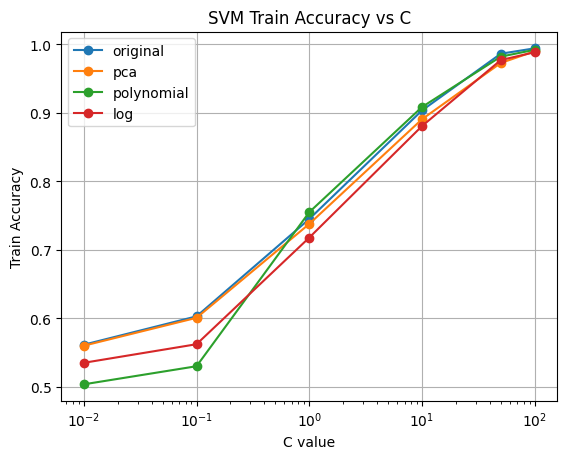

In [111]:
for feature_name in svm_results_df["feature_set"].unique():
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name]
    plt.plot(subset["C"], subset["train_accuracy"], marker="o", label=feature_name)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Train Accuracy")
plt.title("SVM Train Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

Validation accuracy vs C for each feature set

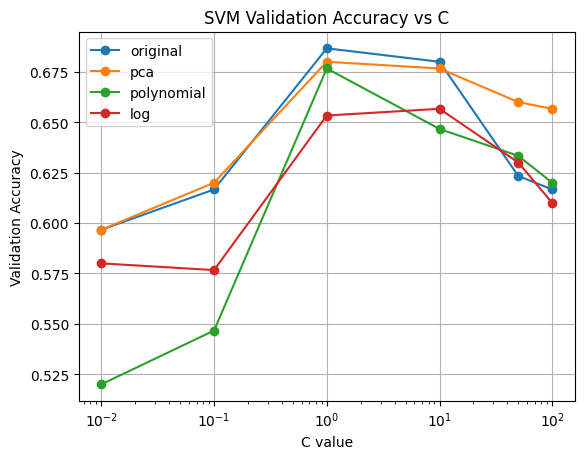

In [112]:
for feature_name in svm_results_df["feature_set"].unique():
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name]
    plt.plot(subset["C"], subset["val_accuracy"], marker="o", label=feature_name)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation Accuracy")
plt.title("SVM Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

Train vs validation accuracy plot

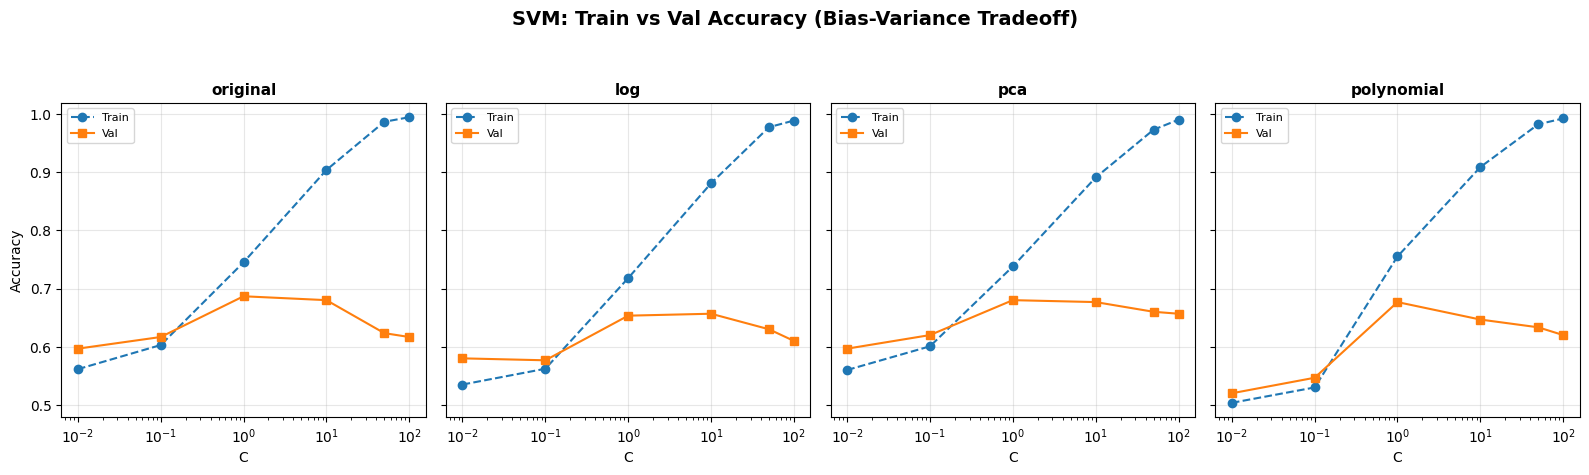

In [113]:
feature_order = ["original", "log", "pca", "polynomial"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.8), sharey=True)
fig.suptitle("SVM: Train vs Val Accuracy (Bias-Variance Tradeoff)", fontsize=14, fontweight="bold")

for ax, feature_name in zip(axes, feature_order):
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name].sort_values("C")
    
    ax.plot(
        subset["C"], subset["train_accuracy"],
        marker="o", linestyle="--", label="Train"
    )
    ax.plot(
        subset["C"], subset["val_accuracy"],
        marker="s", linestyle="-", label="Val"
    )
    
    ax.set_xscale("log")
    ax.set_title(feature_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("C")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Precision, Recall, and F1 score for best SVM Model per Feature Set

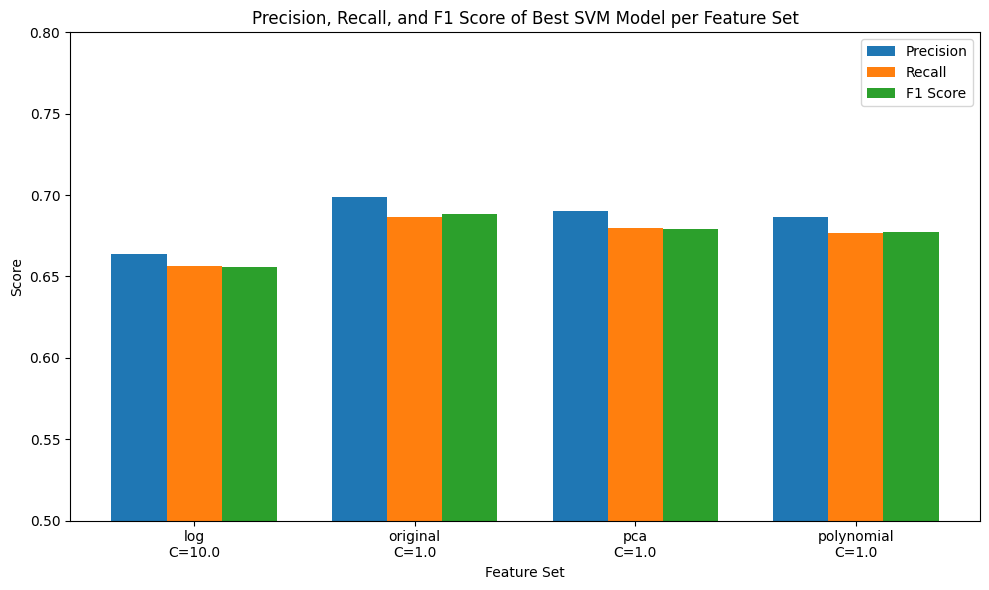

In [114]:
best_per_feature = (
    svm_results_df.loc[
        svm_results_df.groupby("feature_set")["val_accuracy"].idxmax()
    ]
    .sort_values("feature_set")
)

x = np.arange(len(best_per_feature))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, best_per_feature["val_precision"], width, label="Precision")
plt.bar(x,         best_per_feature["val_recall"],    width, label="Recall")
plt.bar(x + width, best_per_feature["val_f1"],        width, label="F1 Score")

plt.xticks(
    x,
    [f"{fs}\nC={c}" for fs, c in zip(best_per_feature["feature_set"], best_per_feature["C"])],
    rotation=0
)

plt.ylabel("Score")
plt.xlabel("Feature Set")
plt.title("Precision, Recall, and F1 Score of Best SVM Model per Feature Set")
plt.ylim(0.5, 0.8)
plt.legend()
plt.tight_layout()
plt.show()

### Test accuracy for the highest validation model from each feature set

In [115]:
best_indices = svm_results_df.groupby("feature_set")["val_accuracy"].idxmax()

best_svm_by_feature = svm_results_df.loc[best_indices]

test_results = []

for idx, row in best_svm_by_feature.iterrows():
    feature_set = row["feature_set"]
    C = row["C"]

    if feature_set == "original":
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled

    elif feature_set == "pca":
        X_train_use = X_train_pca
        X_test_use = X_test_pca

    elif feature_set == "polynomial":
        X_train_use = X_train_poly
        X_test_use = X_test_poly

    elif feature_set == "log":
        X_train_use = X_train_log
        X_test_use = X_test_log

    else:
        raise ValueError(f"Unknown feature set: {feature_set}")

    model = SVC(kernel="rbf", C=C, gamma="scale")
    model.fit(X_train_use, y_train)

    y_test_pred = model.predict(X_test_use)

    test_results.append({
        "feature_set": feature_set,
        "C": C,
        "val_accuracy": row["val_accuracy"],
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    })

test_results_df = pd.DataFrame(test_results).sort_values(
    by="test_accuracy",
    ascending=False
)

test_results_df

,feature_set,C,val_accuracy,test_accuracy,test_precision
2,pca,1.0,0.680000,0.660000,0.671958
1,original,1.0,0.686667,0.656667,0.668317
3,polynomial,1.0,0.676667,0.640000,0.649836
0,log,10.0,0.656667,0.476667,0.486666


Confusion matrix for test predictions

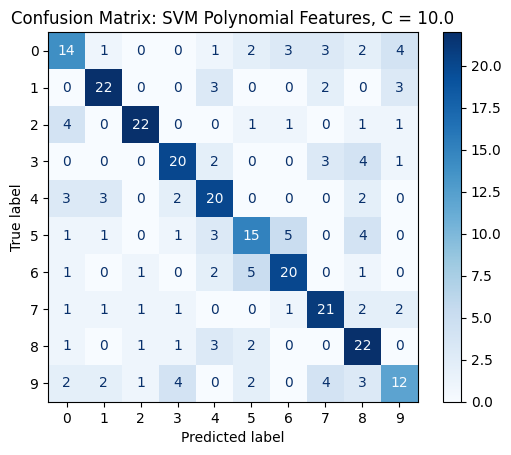

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

poly_svm = SVC(kernel="rbf", C=10.0, gamma="scale")
poly_svm.fit(X_train_poly, y_train)

y_test_pred_poly = poly_svm.predict(X_test_poly)

cm_poly = confusion_matrix(y_test, y_test_pred_poly)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poly,
    display_labels=range(len(label_encoder.classes_))
)

disp.plot(cmap="Blues", xticks_rotation=0)
plt.title("Confusion Matrix: SVM Polynomial Features, C = 10.0")
plt.show()

# Logistic Regression

We will be using softmax for multi class logistic regression.

In [118]:
#reuse the same feature sets already built for SVM
lr_feature_sets = {
    "original": (X_train_scaled, X_val_scaled, X_test_scaled),
    "log": (X_train_log_scaled, X_val_log_scaled, X_test_log_scaled),
    "pca": (X_train_pca, X_val_pca, X_test_pca),
    "polynomial": (X_train_poly, X_val_poly, X_test_poly),
}

C_values = [0.01, 0.1, 1, 10, 50, 100]
lr_results = []

print(lr_feature_sets["original"][0].shape)


(1400, 14)


Training models with different feature sets and respective regularization values

In [119]:
for feature_name, (Xtr, Xv, Xt) in lr_feature_sets.items():
    for c in C_values:
        model = LogisticRegression(C=c, solver='lbfgs', max_iter=2000, random_state=42)
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred = model.predict(Xv)

        lr_results.append({
            "feature_set": feature_name,
            "C": c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0),
        })

/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: Runti

The results table

In [120]:
lr_results_df = pd.DataFrame(lr_results)

#Export results to Excel for easier analysis
lr_results_df.to_excel("lr_results.xlsx", index=False)

best_lr_per_feat = lr_results_df.loc[lr_results_df.groupby('feature_set')['val_accuracy'].idxmax()]

print("Full results table:")
lr_results_df.sort_values(['feature_set', 'C'])

Full results table:


,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
6,log,0.01,0.552143,0.573333,0.559900,0.573333,0.556715
7,log,0.10,0.575714,0.590000,0.582160,0.590000,0.580372
8,log,1.00,0.581429,0.596667,0.589821,0.596667,0.588119
9,log,10.00,0.586429,0.596667,0.591227,0.596667,0.588526
10,log,50.00,0.586429,0.590000,0.586122,0.590000,0.582515
11,log,100.00,0.585714,0.590000,0.586122,0.590000,0.582515
0,original,0.01,0.565000,0.596667,0.597857,0.596667,0.580510
1,original,0.10,0.588571,0.626667,0.616359,0.626667,0.610021
2,original,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
3,original,10.00,0.597143,0.623333,0.614956,0.623333,0.611303


Print the best model for each transformation set

In [121]:
best_lr_row = lr_results_df.loc[lr_results_df['val_accuracy'].idxmax()]
best_lr_per_feat.to_excel("lr_results1.xlsx", index=False)

print(f"\nOverall best: {best_lr_row['feature_set']}  C={best_lr_row['C']}  Val Acc={best_lr_row['val_accuracy']:.4f}")
print("\nBest model per feature set (by Val Acc):")
best_lr_per_feat[['feature_set','C','train_accuracy','val_accuracy','val_f1']]



Overall best: polynomial  C=0.01  Val Acc=0.6667

Best model per feature set (by Val Acc):


,feature_set,C,train_accuracy,val_accuracy,val_f1
8,log,1.00,0.581429,0.596667,0.588119
1,original,0.10,0.588571,0.626667,0.610021
13,pca,0.10,0.573571,0.600000,0.584974
18,polynomial,0.01,0.700714,0.666667,0.667824


Line plot of Val Accuracy vs C value

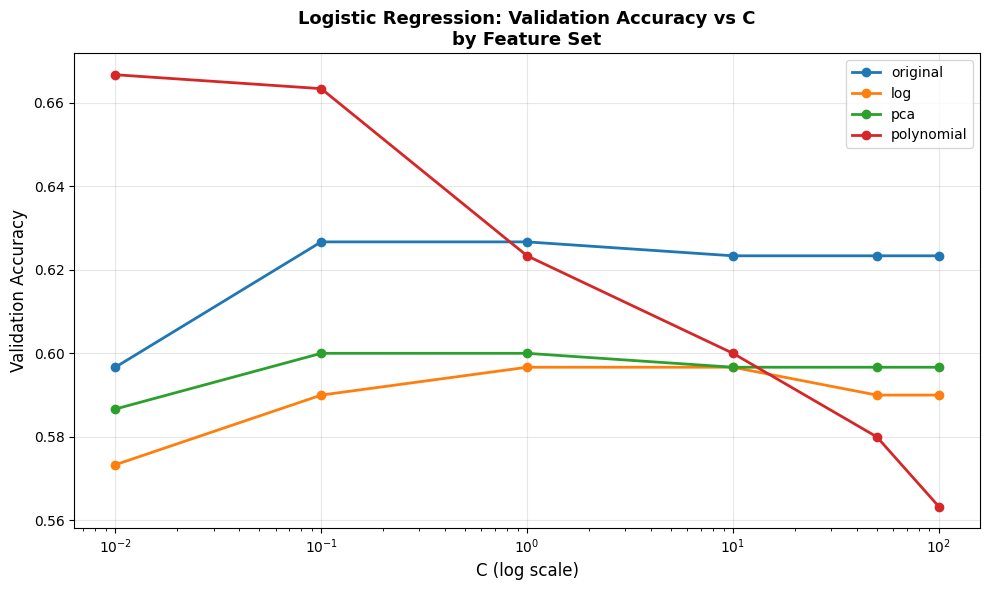

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, feature_name in enumerate(lr_feature_sets):
    subset = lr_results_df[lr_results_df['feature_set'] == feature_name].sort_values('C')
    ax.plot(subset['C'], subset['val_accuracy'], marker='o', linewidth=2,
            color=colors[i], label=feature_name)

ax.set_xscale('log')
ax.set_xlabel('C (log scale)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Logistic Regression: Validation Accuracy vs C\nby Feature Set', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train vs validation accuracy plot

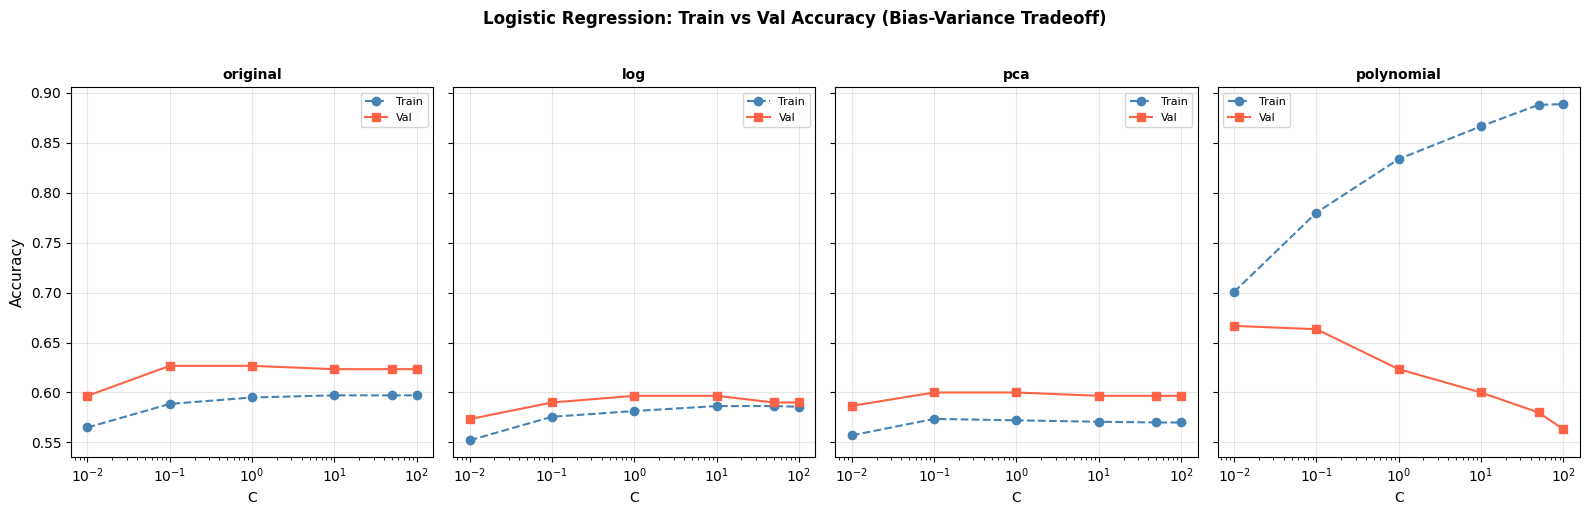

In [123]:
fig, axes = plt.subplots(1, len(lr_feature_sets), figsize=(16, 5), sharey=True)

for i, feature_name in enumerate(lr_feature_sets):
    subset = lr_results_df[lr_results_df['feature_set'] == feature_name].sort_values('C')
    axes[i].plot(subset['C'], subset['train_accuracy'], 'o--', color='steelblue', label='Train')
    axes[i].plot(subset['C'], subset['val_accuracy'],   's-',  color='tomato',    label='Val')
    axes[i].set_xscale('log')
    axes[i].set_title(feature_name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('C', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=11)

fig.suptitle('Logistic Regression: Train vs Val Accuracy (Bias-Variance Tradeoff)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Precision / Recall / F1 — best model per feature set

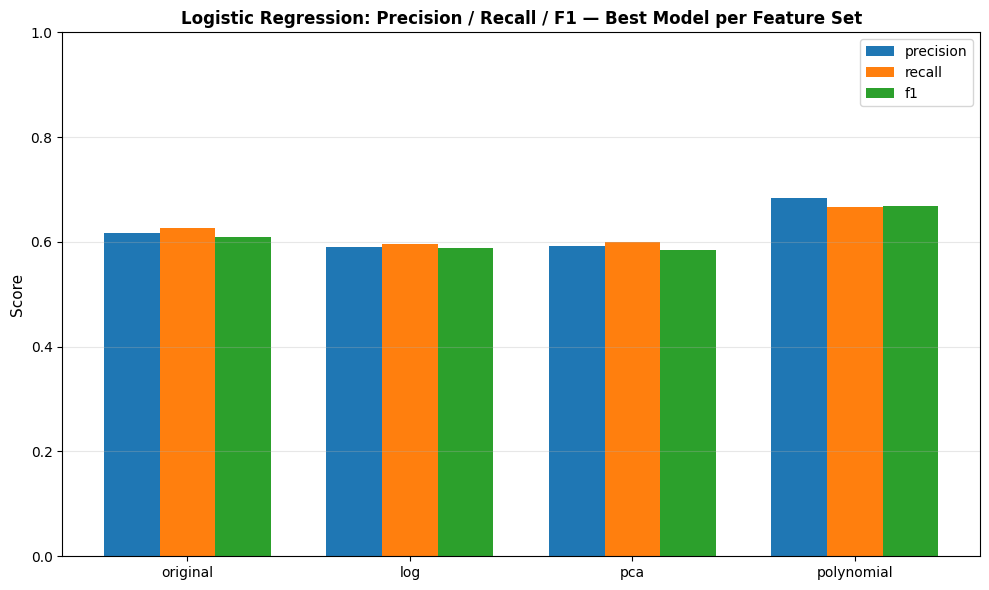

In [124]:
metrics = ['val_precision', 'val_recall', 'val_f1']
feat_names = list(lr_feature_sets.keys())
x = np.arange(len(feat_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for j, metric in enumerate(metrics):
    vals = [best_lr_per_feat[best_lr_per_feat['feature_set'] == f][metric].values[0] for f in feat_names]
    ax.bar(x + j*width, vals, width, label=metric.replace('val_', ''))

ax.set_xticks(x + width)
ax.set_xticklabels(feat_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Logistic Regression: Precision / Recall / F1 — Best Model per Feature Set',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Test eval for best model of each transformation

In [125]:
test_rows = []

for transf in lr_feature_sets:
    #Best C for this transformation from validation results
    best_c = lr_results_df[lr_results_df["feature_set"] == transf].sort_values("val_accuracy", ascending=False).iloc[0]["C"]
    
    Xtr, Xv, Xt = lr_feature_sets[transf]
    
    model = LogisticRegression(C=best_c, solver="lbfgs", max_iter=1000, random_state=42)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xt)
    
    test_rows.append({
        "feature_set": transf,
        "best_C": best_c,
        "test_acc": accuracy_score(y_test, y_pred),
        "test_prec": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "test_rec":recall_score(y_test, y_pred, average="macro", zero_division=0),
        "test_f1":f1_score(y_test, y_pred, average="macro", zero_division=0),
    })
    
test_df = pd.DataFrame(test_rows)
test_df

/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: Runti

,feature_set,best_C,test_acc,test_prec,test_rec,test_f1
0,original,0.10,0.596667,0.593773,0.596667,0.590440
1,log,1.00,0.596667,0.598048,0.596667,0.591653
2,pca,0.10,0.600000,0.607054,0.600000,0.597251
3,polynomial,0.01,0.630000,0.643687,0.630000,0.630963
